# Compute signatures and pairwise whole-genome similarity using sourmash

## ____________________________________________________________________________________________

### Setup libraries, configuration, and directories

In [1]:
## May need to install libraries if not already installed, specifically sourmash, Bio, matplotlib, and numpy ("pip install sourmash", etc.). I believe the rest are included in python. If not, install remaining packages.

In [2]:
## Import libraries

import sourmash
import subprocess
import tempfile
import os
import numpy as np
import matplotlib.pyplot as plt
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio.Phylo import draw
from multiprocessing import Pool
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from functools import partial
import re
import time
import random
import logging
import shutil

In [3]:
## Define working directory with a subdirectory containing genome assemblies, and two directories for containing sourmash signatures and trees

# Define working directory
BASE_DIR = Path("/nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory")
os.chdir(BASE_DIR)


# Create main directories
ASSEMBLY_DIR = BASE_DIR / "Assemblies"
TREE_DIR = BASE_DIR / "SourmashTrees"
SOURMASH_DIR = BASE_DIR / "SourmashSignatures"

In [4]:
## Setup directories and configuration variables


# Configuration variables
K_VALUES = [31]  
SCALED = 1000
SIGNATURE_TIMEOUT = 1800
SOURMASH_THREADS = 32


# Create directories 
for directory in [ASSEMBLY_DIR, TREE_DIR, SOURMASH_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Create subdirectories for each k-value in both SOURMASH_DIR and TREE_DIR
for k in K_VALUES:
    (SOURMASH_DIR / f"k{k}").mkdir(parents=True, exist_ok=True)
    (TREE_DIR / f"k{k}").mkdir(parents=True, exist_ok=True)


# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

### Define some necessary functions

In [5]:
## Create a few functions for sourmash: computing signatures and ANI


# Compute signature for genome assembly
def compute_signature(fna_file, k):
    """Compute sourmash signature for a given k-mer size."""
    sig_path = SOURMASH_DIR / f"k{k}" / f"{fna_file.stem}_k{k}.sig"
    cmd = f"sourmash sketch dna -p k={k},scaled={SCALED} {fna_file} -o {sig_path}"
    try:
        subprocess.run(cmd, shell=True, check=True, capture_output=True, timeout=SIGNATURE_TIMEOUT)
        logging.info(f"Completed signature for {fna_file} with k={k}")
    except (subprocess.CalledProcessError, subprocess.TimeoutExpired) as e:
        logging.error(f"Failed to compute signature for {fna_file} with k={k}: {e}")


In [6]:
# Main processing function for computing comprehensive pairwise ANI for all assemblies using all k-values and both ANI methods
## This is written to handle .fna, .fasta, and .fa extensions. Others will need to be added if need be.

def ComputeSignatures(accessions):
    """Compute signatures and all pairwise ANI comparisons for all accessions and k-values."""

    # Get all successfully extracted assemblies
    fna_files = list(ASSEMBLY_DIR.glob("*.fna")) + list(ASSEMBLY_DIR.glob("*.fasta")) + list(ASSEMBLY_DIR.glob("*.fa"))
    logging.info(f"Found {len(fna_files)}/{len(accessions)} assemblies ready for processing")

    
    # Create k-value directories if needed
    for k in K_VALUES:
        (SOURMASH_DIR / f"k{k}").mkdir(exist_ok=True)
    
    # Compute signatures for all k-values
    logging.info("Computing signatures...")
    with ThreadPoolExecutor(max_workers=SOURMASH_THREADS) as executor:
        for fna_file in fna_files:
            for k in K_VALUES:
                executor.submit(compute_signature, fna_file, k)


In [7]:
## Compute comprehensive ANI comparisons among all assemblies at different k's and ANI estimations

ComputeSignatures(os.listdir(ASSEMBLY_DIR))

2025-11-06 11:35:08,194 - INFO - Found 10/10 assemblies ready for processing


2025-11-06 11:35:08,195 - INFO - Computing signatures...


2025-11-06 11:35:10,815 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA5_filtered.fa with k=31


2025-11-06 11:35:10,840 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA6_filtered.fa with k=31


2025-11-06 11:35:10,886 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA36_filtered.fa with k=31


...

2025-11-06 11:35:10,997 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA24_filtered.fa with k=31


2025-11-06 11:35:11,039 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/JKU12_filtered.fa with k=31


2025-11-06 11:35:11,098 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA31_filtered.fa with k=31


2025-11-06 11:35:12,079 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA9_filtered.fa with k=31


2025-11-06 11:35:12,876 - INFO - Completed signature for /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/Assemblies/KRA11_filtered.fa with k=31


In [8]:
def compute_comprehensive_ani(k):
    """Compute ANI matrices for all available signatures at a given k-value."""
    k_dir = SOURMASH_DIR / f"k{k}"
    
    # Get all signature files for this k-value
    sig_files = list(k_dir.glob(f"*_k{k}.sig"))
    
    if not sig_files:
        logging.error(f"No signature files found for k={k}")
        return
    
    # Create signature list file
    sig_list = k_dir / "all_signatures.txt"
    with open(sig_list, "w") as f:
        for sig_file in sig_files:
            f.write(f"{sig_file}\n")
    
    # Compute Jaccard ANI matrix
    jaccard_out = k_dir / "comprehensive_jaccard.npy"
    jaccard_cmd = f"sourmash compare --from-file {sig_list} -k {k} --ani -o {jaccard_out}"
    subprocess.run(jaccard_cmd, shell=True, check=True)
    
    # Compute Max-Containment ANI matrix
    containment_out = k_dir / "comprehensive_maxcontainment.npy"
    containment_cmd = f"sourmash compare --from-file {sig_list} -k {k} --max-containment --ani -o {containment_out}"
    subprocess.run(containment_cmd, shell=True, check=True)
    
    # Save accession order for reference
    accessions = [sig_file.stem.replace(f"_k{k}", "") for sig_file in sig_files]
    with open(k_dir / "accession_order.txt", "w") as f:
        f.write("\n".join(accessions))
    
    logging.info(f"Completed ANI calculations for k={k} with {len(sig_files)} signatures")


In [9]:
# Run for all k-values
for k in K_VALUES:
    compute_comprehensive_ani(k)


0-/nfs4/BPP/Uehli...	[1.    0.87  0.867 0.983 0.805 0.869 0.869 0.871 0.868 0.868]
1-/nfs4/BPP/Uehli...	[0.87  1.    0.877 0.876 0.805 0.877 0.98  0.997 0.877 0.866]
2-/nfs4/BPP/Uehli...	[0.867 0.877 1.    0.873 0.806 0.98  0.876 0.877 0.997 0.864]
3-/nfs4/BPP/Uehli...	[0.983 0.876 0.873 1.    0.809 0.874 0.875 0.877 0.874 0.872]
4-/nfs4/BPP/Uehli...	[0.805 0.805 0.806 0.809 1.    0.806 0.806 0.805 0.805 0.8  ]
5-/nfs4/BPP/Uehli...	[0.869 0.877 0.98  0.874 0.806 1.    0.876 0.877 0.98  0.864]
6-/nfs4/BPP/Uehli...	[0.869 0.98  0.876 0.875 0.806 0.876 1.    0.98  0.876 0.865]
7-/nfs4/BPP/Uehli...	[0.871 0.997 0.877 0.877 0.805 0.877 0.98  1.    0.877 0.866]
8-/nfs4/BPP/Uehli...	[0.868 0.877 0.997 0.874 0.805 0.98  0.876 0.877 1.    0.864]
9-/nfs4/BPP/Uehli...	[0.868 0.866 0.864 0.872 0.8   0.864 0.865 0.866 0.864 1.   ]
min similarity in matrix: 0.800



== This is sourmash version 4.8.4. ==
== Please cite Brown and Irber (2016), doi:10.21105/joss.00027. ==

loaded 10 signatures total.

saving labels to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashSignatures/k31/comprehensive_jaccard.npy.labels.txt
saving comparison matrix to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashSignatures/k31/comprehensive_jaccard.npy



== This is sourmash version 4.8.4. ==
== Please cite Brown and Irber (2016), doi:10.21105/joss.00027. ==

loaded 10 signatures total.

saving labels to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashSignatures/k31/comprehensive_maxcontainment.npy.labels.txt
saving comparison matrix to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashSignatures/k31/comprehensive_maxcontainment.npy
2025-11-06 11:35:15,056 - INFO - Completed ANI calculations for k=31 with 10 signatures


0-/nfs4/BPP/Uehli...	[1.    0.876 0.875 0.877 0.876 0.876 0.98  0.811 0.874 0.98 ]
1-/nfs4/BPP/Uehli...	[0.876 1.    0.874 0.876 0.98  0.98  0.877 0.811 0.872 0.877]
2-/nfs4/BPP/Uehli...	[0.875 0.874 1.    0.992 0.874 0.873 0.877 0.813 0.881 0.876]
3-/nfs4/BPP/Uehli...	[0.877 0.876 0.992 1.    0.876 0.875 0.879 0.819 0.868 0.879]
4-/nfs4/BPP/Uehli...	[0.876 0.98  0.874 0.876 1.    0.997 0.877 0.81  0.873 0.877]
5-/nfs4/BPP/Uehli...	[0.876 0.98  0.873 0.875 0.997 1.    0.877 0.811 0.872 0.877]
6-/nfs4/BPP/Uehli...	[0.98  0.877 0.877 0.879 0.877 0.877 1.    0.81  0.875 0.997]
7-/nfs4/BPP/Uehli...	[0.811 0.811 0.813 0.819 0.81  0.811 0.81  1.    0.814 0.809]
8-/nfs4/BPP/Uehli...	[0.874 0.872 0.881 0.868 0.873 0.872 0.875 0.814 1.    0.875]
9-/nfs4/BPP/Uehli...	[0.98  0.877 0.876 0.879 0.877 0.877 0.997 0.809 0.875 1.   ]
min similarity in matrix: 0.809


## Now produce and save the sourmash tree

#### Load the data

In [10]:
# Load the k=31 matrix
k31_path_j = SOURMASH_DIR / "k31/comprehensive_maxcontainment.npy"


ani_31_j = np.load(k31_path_j)

# Load the labels for both k values
k31_labels_path_j = SOURMASH_DIR / "k31/comprehensive_maxcontainment.npy.labels.txt"

def parse_labels(label_file):
    with open(label_file) as f:
        labels = [line.strip() for line in f]
    # Parse labels to get just the accession (GCA_XXXXXX.X)
    parsed_labels = []
    for label in labels:
        # Get the filename part after the last '/'
        filename = label.split('/')[-1]
        # Split by '_' and take first two parts
        accession = '_'.join(filename.split('_')[:2])
        parsed_labels.append(accession)
    return parsed_labels


k31_labels_j = parse_labels(k31_labels_path_j)


#### Build the tree

In [11]:
## For k=31

# Convert similarity matrix to distance matrix
DistMatrix = 1 - ani_31_j

# Condense to lower-triangular format
num_taxa = len(ani_31_j)
condensed_matrix = []
for i in range(num_taxa):
    condensed_matrix.append(DistMatrix[i, :i+1].tolist())

# Create BioPython DistanceMatrix object
dist_matrix = DistanceMatrix(names=k31_labels_j, matrix=condensed_matrix)

# Build UPGMA tree
constructor = DistanceTreeConstructor()
upgma_tree_31 = constructor.upgma(dist_matrix)
upgma_tree_31.ladderize()  


## Save the tree 
# Define the output file path
output_path = os.path.join(TREE_DIR, "k31/upgma_tree_k31_maxcontainment.newick")

# Save the tree in Newick format
Phylo.write(upgma_tree_31, output_path, "newick")

print(f"Tree saved to: {output_path}")

Tree saved to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashTrees/k31/upgma_tree_k31_maxcontainment.newick


#### Plot and save the tree

In [12]:
## this function hides the internal node labels, these are usually bootstrap scores but there aren't any for an ANI tree like this

# Function to hide internal node labels
def hide_inner_labels(clade):
    return "" if not clade.is_terminal() else clade.name

Tree plot saved to: /nfs4/BPP/Uehling_Lab/johnsh/WholeGenomeSimilarityTree/PracticeDirectory/SourmashTrees/k31/upgma_tree_k31_maxcontainment.png


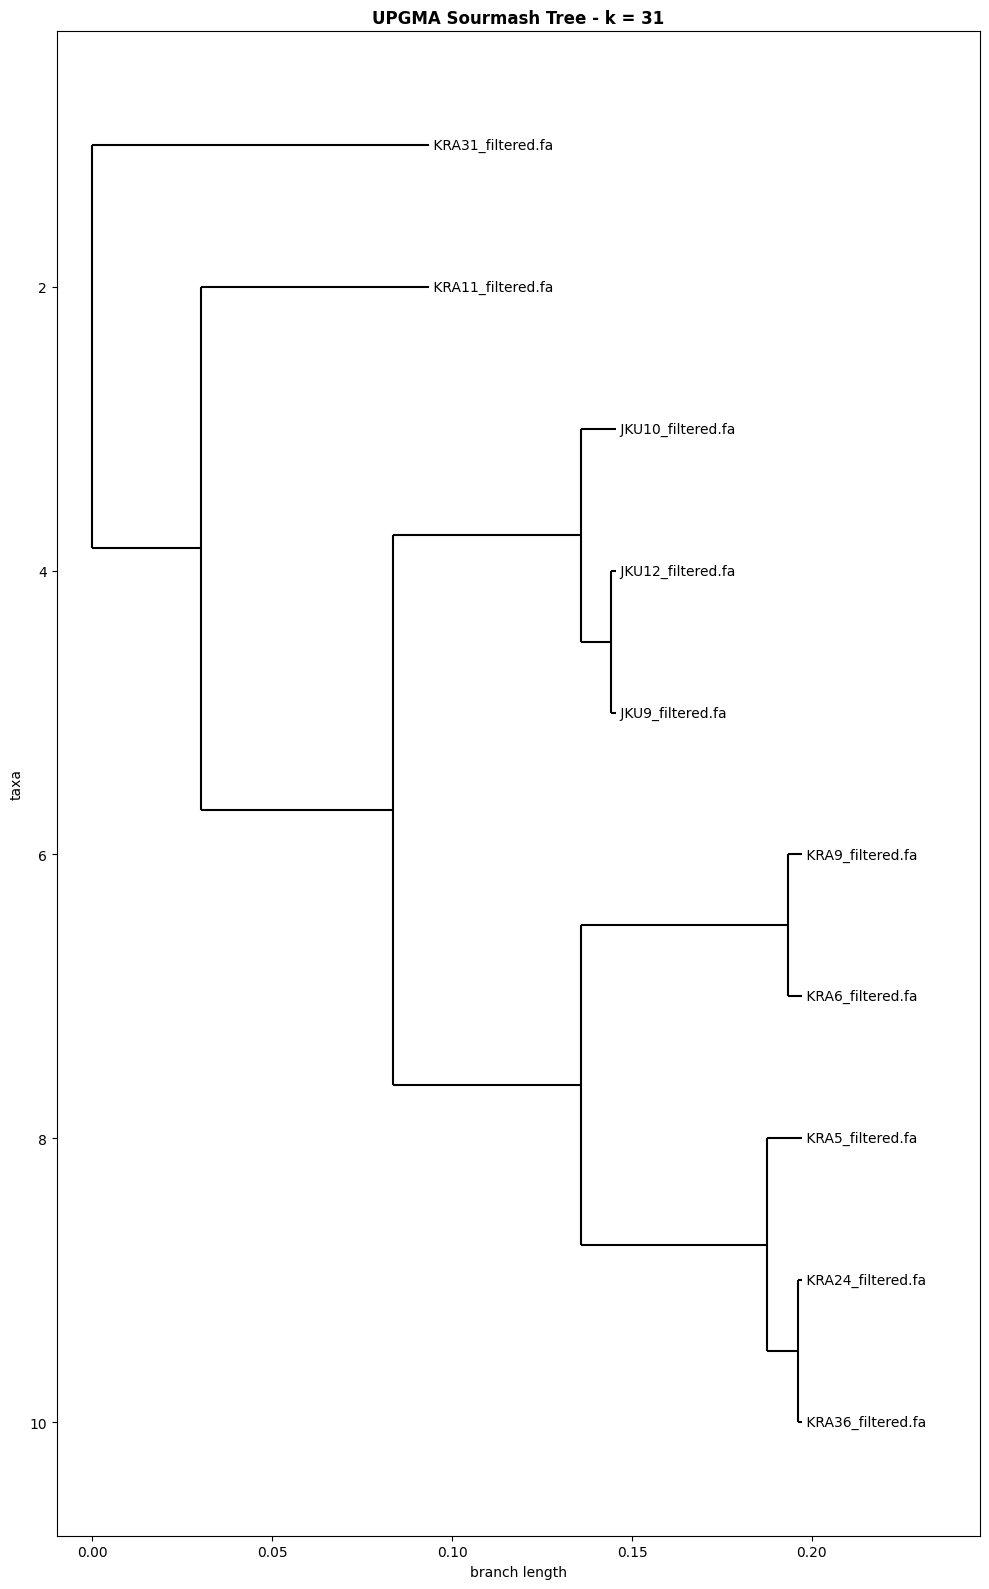

In [13]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 16))

# Plot the tree onto that axis
Phylo.draw(upgma_tree_31, axes=ax, do_show=False, label_func=hide_inner_labels)

# Add title to that axis
ax.set_title("UPGMA Sourmash Tree - k = 31", fontsize=12, fontweight='bold')

# Tight layout to prevent clipping
plt.tight_layout()

# Save the figure
tree_plot_path = TREE_DIR / "k31/upgma_tree_k31_maxcontainment.png"
plt.savefig(tree_plot_path, dpi=300, bbox_inches="tight")

print(f"Tree plot saved to: {tree_plot_path}")